In [210]:
import os
import numpy as np
import matplotlib.pyplot as plt

def find_learning_curves(root_folder):
    """
    Busca recursivamente por arquivos 'learning_process.txt' em uma pasta.
    
    Args:
        root_folder (str): O caminho para a pasta principal contendo os modelos.

    Returns:
        list: Uma lista de caminhos para cada arquivo encontrado.
    """
    filepaths = []
    for dirpath, _, filenames in os.walk(root_folder):
        if 'learning_process.txt' in filenames:
            filepaths.append(os.path.join(dirpath, 'learning_process.txt'))
    return filepaths

def load_and_process_curves(filepaths):
    """
    Carrega os dados das curvas de aprendizado, lidando com diferentes comprimentos.

    Args:
        filepaths (list): Lista de caminhos para os arquivos de curva de aprendizado.

    Returns:
        np.ndarray: Uma matriz onde cada linha é uma curva de aprendizado,
                    preenchida com NaN para simulações mais curtas.
    """
    if not filepaths:
        return np.array([])

    # Carrega todas as curvas
    curves = [np.loadtxt(fp, delimiter=',') for fp in filepaths]
    
    # Encontra o comprimento máximo (número máximo de episódios) entre todas as simulações
    try:
        max_len = max(len(curve) for curve in curves if hasattr(curve, '__len__'))
    except ValueError: # Caso onde todas as curvas têm um único elemento
        max_len = 1
    
    # Cria uma matriz de NaNs (Not a Number) com o formato (num_curvas, max_len)
    processed_curves = np.full((len(curves), max_len), np.nan)
    
    # Preenche a matriz com os dados de cada curva
    for i, curve in enumerate(curves):
        if hasattr(curve, '__len__'):
            processed_curves[i, :len(curve)] = curve
        else: # Caso de curva com um único ponto
            processed_curves[i, 0] = curve
            
    return processed_curves

def plot_average_curve(curves, folder_name):
    """
    Calcula e plota a média e o desvio padrão das curvas de aprendizado.

    Args:
        curves (np.ndarray): Matriz de curvas de aprendizado.
        folder_name (str): Nome da pasta para usar no título do gráfico.
    """
    if curves.size == 0:
        print("Nenhuma curva de aprendizado para plotar.")
        return

    # Calcula a média e o desvio padrão ao longo das colunas (episódios)
    # np.nanmean e np.nanstd ignoram os valores NaN, o que é crucial
    mean_curve = np.nanmean(curves, axis=0)
    std_curve = np.nanstd(curves, axis=0)
    
    # Define os limites superior e inferior para a área sombreada
    upper_bound = mean_curve + std_curve
    lower_bound = mean_curve - std_curve
    
    # Número de episódios para o eixo x
    episodes = np.arange(len(mean_curve))

    # --- Criação do Gráfico ---
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(12, 8))

    # Plota a curva média
    ax.plot(episodes, mean_curve, color='royalblue', lw=2.5, label='Média da Curva de Aprendizado')
    
    # Plota a área sombreada para o desvio padrão
    ax.fill_between(episodes, lower_bound, upper_bound, color='royalblue', alpha=0.2, label='Desvio Padrão (±1σ)')

    ax.set_title(f'Curva de Aprendizado Média\n(Pasta: {folder_name})', fontsize=18, pad=20)
    ax.set_xlabel('Episódio', fontsize=14)
    ax.set_ylabel('Passos Normalizados até o Alvo', fontsize=14)
    ax.legend(fontsize=12)
    ax.grid(True)
    
    # Melhora os limites do gráfico
    ax.set_xlim(0, len(mean_curve) - 1 if len(mean_curve) > 1 else 1)
    ax.set_ylim(bottom=0)

    plt.tight_layout()
    plt.show()

In [211]:
os.listdir('../data/models')

['baseline_slide',
 '.ipynb_checkpoints',
 'novo_colision_slide_k=2_R=0_P=20',
 'baseline_periodico',
 'novo_colision_slide_k=1_R=0_P=50',
 'novo_colision_slide_k=2_R=0_P=50',
 'novo_colision_slide_k=1_R=0_P=20',
 'novo_colision_slide_k=0_R=0_P=20',
 'del model.ipynb',
 'novo_colision_slide_k=0_R=0_P=50']

Encontrados 1 modelos para análise.


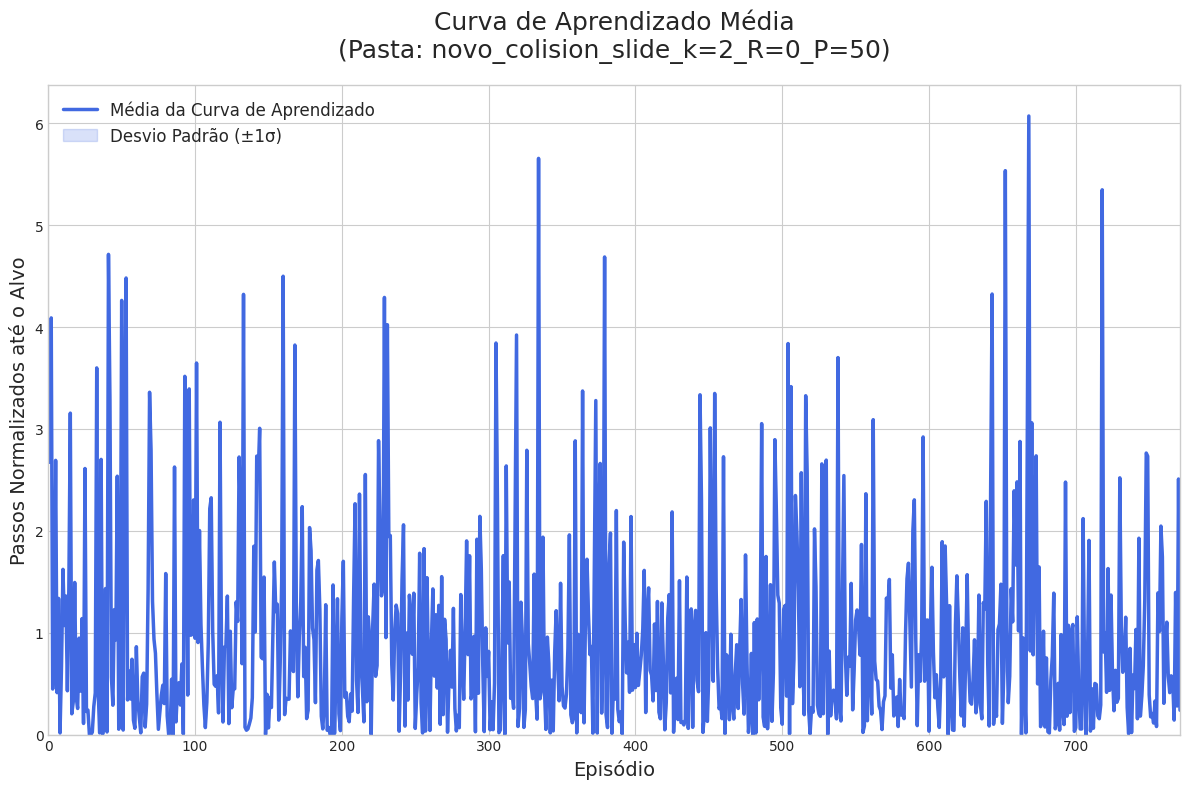

In [220]:
# 1. ESPECIFIQUE O CAMINHO DA PASTA AQUI
folder_to_analyze = "../data/models/novo_colision_slide_k=2_R=0_P=50"

# 2. EXECUTE A ANÁLISE
if not os.path.isdir(folder_to_analyze):
    print(f"ERRO: A pasta especificada não foi encontrada: '{folder_to_analyze}'")
    print("Por favor, verifique se o caminho está correto.")
else:
    # Encontra todos os arquivos de curva de aprendizado
    filepaths = find_learning_curves(folder_to_analyze)
    
    if not filepaths:
        print(f"Nenhum arquivo 'learning_process.txt' encontrado em '{folder_to_analyze}'.")
    else:
        print(f"Encontrados {len(filepaths)} modelos para análise.")

        # Carrega e processa os dados
        all_curves = load_and_process_curves(filepaths)
        
        # Plota o resultado
        folder_name = os.path.basename(folder_to_analyze)
        plot_average_curve(all_curves, folder_name)